In [1]:
import json
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from imblearn.over_sampling import ADASYN
from sklearn.model_selection import train_test_split, StratifiedKFold
from scipy.stats import pointbiserialr
import xgboost as xgb
from gplearn.genetic import SymbolicRegressor
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
Cards = pd.read_csv("./data/cards_data.csv")
Transactions = pd.read_csv("./data/transactions_data.csv")
Users = pd.read_csv("./data/users_data.csv")

In [3]:
Cards['credit_limit'] = Cards['credit_limit'].replace('[\$,]', '', regex=True).astype(float)
Users['yearly_income'] = Users['yearly_income'].replace('[\$,]', '', regex=True).astype(float)
Users['total_debt'] = Users['total_debt'].replace('[\$,]', '', regex=True).astype(float)
Users['per_capita_income'] = Users['per_capita_income'].replace('[\$,]', '', regex=True).astype(float)
Transactions['amount'] = Transactions['amount'].replace('[\$,]', '', regex=True).astype(float)

# 合併三表
Trans_merge = pd.DataFrame()
Trans_merge = Transactions.merge(Cards, left_on="card_id", right_on="id", suffixes=("_txn","_card"))
Trans_merge = Trans_merge.merge(Users, left_on="client_id_txn", right_on="id", suffixes=("","_user"))

In [4]:
Trans_merge['date'] = pd.to_datetime(Trans_merge['date'])

## 每小時交易量
Trans_merge['hour'] = Trans_merge['date'].dt.floor('H')

hourly_volume = (
    Trans_merge
    .groupby(['client_id_txn', 'hour'])['amount']
    .sum()
    .reset_index()
    .rename(columns={'amount': 'hourly_transaction_volume'})
)

if 'hourly_transaction_volume' in Trans_merge.columns:
    Trans_merge = Trans_merge.drop(columns=['hourly_transaction_volume'])
    
Trans_merge = Trans_merge.merge(
    hourly_volume,
    on=['client_id_txn', 'hour'],
    how='left'
)

In [5]:
with open('./data/train_fraud_labels.json', 'r') as f:
    fraud_data = json.load(f)

fraud_dict = fraud_data['target']

fraud_dict = {int(k): v for k, v in fraud_dict.items()}

Trans_merge['id_txn'] = Trans_merge['id_txn'].astype(int)

Trans_merge['is_fraud'] = Trans_merge['id_txn'].map(fraud_dict)
Trans_merge = Trans_merge[Trans_merge['is_fraud'].notna()].copy()
Trans_merge['is_fraud'] = Trans_merge['is_fraud'].map({'Yes': 1, 'No': 0})

In [6]:
columns_to_drop = ['id_txn', 'client_id_txn', 'card_id', 'merchant_id', 'date']
Trans_merge = Trans_merge.drop(columns=columns_to_drop)

Trans_merge.info()

print(Trans_merge['is_fraud'].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 8914963 entries, 0 to 13305912
Data columns (total 37 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   amount                     float64       
 1   use_chip                   object        
 2   merchant_city              object        
 3   merchant_state             object        
 4   zip                        float64       
 5   mcc                        int64         
 6   errors                     object        
 7   id_card                    int64         
 8   client_id_card             int64         
 9   card_brand                 object        
 10  card_type                  object        
 11  card_number                int64         
 12  expires                    object        
 13  cvv                        int64         
 14  has_chip                   object        
 15  num_cards_issued           int64         
 16  credit_limit               float64      

In [7]:
print("--- 原始資料 (Trans_merge) 檢查 ---")
print(f"原始資料形狀: {Trans_merge.shape}")
print("\n原始資料類型 (前 10 欄):")
print(Trans_merge.iloc[:, :10].dtypes)
print("\n原始資料遺失值數量 (前 10 欄):")
print(Trans_merge.iloc[:, :10].isnull().sum())
print("------------------------------------\n")

--- 原始資料 (Trans_merge) 檢查 ---
原始資料形狀: (8914963, 37)

原始資料類型 (前 10 欄):
amount            float64
use_chip           object
merchant_city      object
merchant_state     object
zip               float64
mcc                 int64
errors             object
id_card             int64
client_id_card      int64
card_brand         object
dtype: object

原始資料遺失值數量 (前 10 欄):
amount                  0
use_chip                0
merchant_city           0
merchant_state    1047865
zip               1107377
mcc                     0
errors            8773196
id_card                 0
client_id_card          0
card_brand              0
dtype: int64
------------------------------------



In [8]:
import time
from tqdm import tqdm

tqdm.pandas()

start_time = time.time()

df = Trans_merge.copy()
TARGET_COLUMN = 'is_fraud'

print("==== Step 1: 移除遺失值過高欄位 ====")
missing_ratio = df.isnull().mean()
cols_to_drop = missing_ratio[missing_ratio > 0.7].index
print(f"以下欄位遺失超過 70%：{list(cols_to_drop)}")
df.drop(columns=cols_to_drop, inplace=True)
print(f"已移除 {len(cols_to_drop)} 個欄位。\n")

print("==== Step 2: 處理類別特徵與數值轉換 (已修正高基數) ====")

# 1. 識別所有類別欄位
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if not categorical_cols:
    print("未發現非數值欄位，跳過編碼。")
else:
    HIGH_CARDINALITY_THRESHOLD = 50 # 自定義閾值
    low_card_cols = [col for col in categorical_cols if df[col].nunique() <= HIGH_CARDINALITY_THRESHOLD]
    high_card_cols = [col for col in categorical_cols if df[col].nunique() > HIGH_CARDINALITY_THRESHOLD]
    
    # a. 對低基數欄位執行 One-Hot Encoding
    if low_card_cols:
        print(f"  👉 低基數欄位 ({len(low_card_cols)}個): 執行 OHE")
        df = pd.get_dummies(df, columns=low_card_cols, dummy_na=False)
        
    # b. 對高基數欄位執行頻率編碼 (Frequency Encoding)
    if high_card_cols:
        print(f"  👉 高基數欄位 ({len(high_card_cols)}個): 執行頻率編碼 (降維)")
        for col in high_card_cols:
            freq_map = df[col].value_counts(normalize=True).to_dict()
            df[col] = df[col].map(freq_map)
            # 現在這些欄位已經變成數值 (頻率)
            
# 2. 最終數值轉換 (保持原狀，處理潛在的轉換錯誤)
for col in tqdm(df.columns, desc="Final numerical conversion"):
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("\n=== Step 3: 遺失值填補 (column-by-column SimpleImputer) ===")
cols_to_impute = df.columns[df.isnull().any()]
print(f"需要填補遺失值的欄位數：{len(cols_to_impute)}")

from sklearn.impute import SimpleImputer

for col in cols_to_impute:
    try:
        imputer = SimpleImputer(strategy="median")
        df[[col]] = imputer.fit_transform(df[[col]])
    except Exception as e:
        print(f"⚠️ 欄位 {col} 無法使用 median 填補，改用常數 0。錯誤：{e}")
        df[col] = df[col].fillna(0)
        
print("\n==== Step 4: 數據標準化 ====")
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

print("RobustScaler 執行中...")
X_robust = pd.DataFrame(RobustScaler().fit_transform(X), columns=X.columns)

print("MinMaxScaler 執行中...")
X_scaled = pd.DataFrame(MinMaxScaler().fit_transform(X_robust), columns=X.columns)

print("➡️ 數據縮放完成\n")


print("==== Step 5: train-test split ====")
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=34, stratify=y
)

print(f"訓練集: {len(X_train)}  | 測試集: {len(X_test)}\n")

==== Step 1: 移除遺失值過高欄位 ====
以下欄位遺失超過 70%：['errors']
已移除 1 個欄位。

==== Step 2: 處理類別特徵與數值轉換 (已修正高基數) ====
  👉 低基數欄位 (6個): 執行 OHE
  👉 高基數欄位 (5個): 執行頻率編碼 (降維)


Final numerical conversion: 100%|██████████████████████████████████████████████████████| 45/45 [00:00<00:00, 78.53it/s]



=== Step 3: 遺失值填補 (column-by-column SimpleImputer) ===
需要填補遺失值的欄位數：2

==== Step 4: 數據標準化 ====
RobustScaler 執行中...
MinMaxScaler 執行中...
➡️ 數據縮放完成

==== Step 5: train-test split ====
訓練集: 6240474  | 測試集: 2674489



In [9]:
# ==== 檢查點 3: 最終訓練數據 (在 Step 6 之後) ====
# 假設最終訓練數據是 X_train 和 y_train
print("--- 最終訓練數據 (X_train, y_train) 檢查 ---")
print(f"最終訓練集形狀: {X_train.shape}")
print(f"目標欄位 {TARGET_COLUMN} 的資料類型: {y_train.dtype}")
print(f"最終舞弊比例 (平均值): {y_train.mean():.4f}")
print("\n特徵 (X_train) 的統計概況 (前 5 欄):")
# 檢查標準化是否成功 (MinMaxScaler 應該讓 Min=0, Max=1)
print(X_train.iloc[:, :5].describe().loc[['min', 'max']])
print("------------------------------------\n")

--- 最終訓練數據 (X_train, y_train) 檢查 ---
最終訓練集形狀: (6240474, 44)
目標欄位 is_fraud 的資料類型: int64
最終舞弊比例 (平均值): 0.0015

特徵 (X_train) 的統計概況 (前 5 欄):
       amount  merchant_city  merchant_state  zip  mcc
min  0.000000            0.0             0.0  0.0  0.0
max  0.871137            1.0             1.0  1.0  1.0
------------------------------------



In [23]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score, average_precision_score, accuracy_score
)

# 使用 X_train 的所有欄位作為特徵集
features = X_train.columns.tolist()

# --------------------------------------
# Step 1: 準備訓練資料與測試資料
# --------------------------------------
try:
    X_train_fs = X_train[features]  # 使用所有特徵
    X_test_fs = X_test[features]
except KeyError:
    raise ValueError("特徵集欄位不存在於訓練資料或測試資料中。")

# --------------------------------------
# Step 2: 訓練模型並使用自訂閾值 (0.3)
# --------------------------------------
from sklearn.linear_model import LogisticRegression

# 1. 設定您想要的閾值
THRESHOLD = 0.05

# 2. 訓練模型
model = LogisticRegression(max_iter=5000, random_state=34)
model.fit(X_train_fs, y_train)

# 3. 取得「測試集」機率 (原本是用 predict，現在改用機率)
y_test_prob = model.predict_proba(X_test_fs)[:, 1]

# 4. 【關鍵修改】手動用 0.3 來切分
# 如果機率 >= 0.3 就是 1，否則就是 0
y_test_pred = (y_test_prob >= THRESHOLD).astype(int)


# --------------------------------------
# Step 3: 計算測試集的各項指標 (這部分不用變，變數名稱都一樣)
# --------------------------------------
test_accuracy   = accuracy_score(y_test, y_test_pred)
test_f1         = f1_score(y_test, y_test_pred)
test_precision  = precision_score(y_test, y_test_pred, zero_division=0)
test_recall     = recall_score(y_test, y_test_pred, zero_division=0)
test_auc        = roc_auc_score(y_test, y_test_prob)
test_pr_auc     = average_precision_score(y_test, y_test_prob)

# --------------------------------------
# Step 4: 計算訓練集的各項指標 (也要同步改成 0.3)
# --------------------------------------
# 取得「訓練集」機率
y_train_prob = model.predict_proba(X_train_fs)[:, 1]

# 【關鍵修改】訓練集也用 0.3 切分
y_train_pred = (y_train_prob >= THRESHOLD).astype(int)

# 計算訓練集的指標
train_accuracy  = accuracy_score(y_train, y_train_pred)
train_f1        = f1_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, zero_division=0)
train_recall    = recall_score(y_train, y_train_pred, zero_division=0)
train_auc       = roc_auc_score(y_train, y_train_prob)
train_pr_auc    = average_precision_score(y_train, y_train_prob)

# (後面的 results 字典儲存不用改)

🚀 Model Results:  {'Features_Count': 44, 'train_accuracy': 0.9985046007723132, 'train_f1': 0.0, 'train_precision': 0.0, 'train_recall': 0.0, 'train_auc': 0.8687364277181496, 'train_pr_auc': 0.013416730245233386, 'test_accuracy': 0.9985043871932171, 'test_f1': 0.0, 'test_precision': 0.0, 'test_recall': 0.0, 'test_auc': 0.8683101032245405, 'test_pr_auc': 0.014063630559373529}


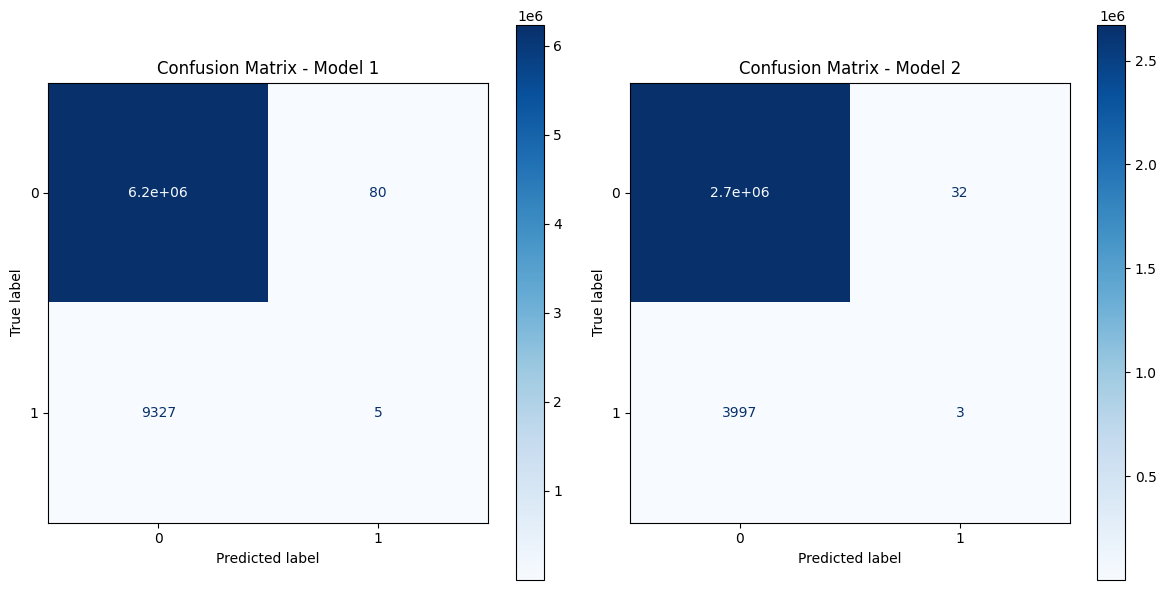

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("🚀 Model Results: ", results)

# 計算混淆矩陣
cm1 = confusion_matrix(y_train, y_train_pred)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=model.classes_)

cm2 = confusion_matrix(y_test, y_test_pred) 
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=model.classes_)

# 創建畫布並並排顯示兩個混淆矩陣
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 在第一個子圖上顯示第一個混淆矩陣
disp1.plot(ax=axes[0], cmap=plt.cm.Blues)
axes[0].set_title("Confusion Matrix - Model 1")

# 在第二個子圖上顯示第二個混淆矩陣
disp2.plot(ax=axes[1], cmap=plt.cm.Blues)
axes[1].set_title("Confusion Matrix - Model 2")

plt.tight_layout()
plt.show()
